In [1]:
import pandas as pd
import csv

In [2]:
df = pd.read_csv("Main1_combined.csv", delimiter = ',', encoding='utf-8')

In [4]:
df

,ID,text,tag_tamara,tag_katja,comments_tamara,comments_katja,flagged_tamara,flagged_katja,chair,final_tag
0,ParlaMint-SI_2010-09-07-SDZ5-Izredna-28.u90,"Ni replike na repliko. Gospa ministrica, potem...",N_Neutral,N_Neutral,"Procedural, but he is denying her the ability ...","Procedural, however still has relatively stron...",NaN,NaN,True,NaN
1,ParlaMint-SI_2011-06-16-SDZ5-Redna-29.u107,Hvala lepa. Besedo ima Silva Črnugelj. Priprav...,P_Neutral,P_Neutral,Procedural.,NaN,NaN,NaN,True,NaN
2,ParlaMint-SI_2011-06-21-SDZ5-Redna-29.u178,"Hvala lepa. V bistvu se strinjam z vami, gospo...",Positive,Positive,Speaker is stating positive changes and support.,"Speech seems to be fairly positive, as the spe...",NaN,NaN,False,NaN
3,ParlaMint-SI_2020-09-21-SDZ8-Redna-20.u276,"Hvala, podpredsednik. Hvala tudi za vprašanje,...",Negative,Negative,"Negative opinion of the topic, the work done, ...",Could also be Mixed sentiment due to the last ...,NaN,True,False,NaN
4,ParlaMint-SI_2009-11-18-SDZ5-Redna-11.u120,Besedo ima gospod Silven Majhenič.,P_Neutral,P_Neutral,Procedural,NaN,NaN,NaN,True,NaN
...,...,...,...,...,...,...,...,...,...,...
195,ParlaMint-SI_2009-07-10-SDZ5-Redna-08.u230,Hvala lepa za besedo. Poslanci DeSUS predlagan...,Negative,Negative,"Not supporting the core of the talk, supportin...",Explicit opitnion of the speaker/party that th...,NaN,NaN,False,NaN
196,ParlaMint-SI_2006-07-14-SDZ4-Redna-19.u56,[[...]]se zgodijo nepravilnosti in jaz si ne ž...,M_Positive,M_Positive,"Second part positive and first part negative, ...",NaN,NaN,NaN,False,NaN
197,ParlaMint-SI_2008-06-16-SDZ4-Redna-40.u121,Hvala lepa. Zelo podobno vprašanje je gospa po...,M_Negative,Negative,Although there are some positive stuff written...,Very defensive answer on a question - I would ...,NaN,True,False,NaN
198,ParlaMint-SI_2021-03-30-SDZ8-Izredna-67.u29,"Hvala lepa. Kolega Cigler, replika.",P_Neutral,P_Neutral,Procedural,NaN,NaN,NaN,True,NaN


# 6-level schema analysis (Cohen's Kappa (κ))

In [5]:
from sklearn.metrics import cohen_kappa_score
annotator1 = df['tag_tamara']
annotator2 = df['tag_katja']
cohen_kappa_score(annotator1, annotator2)

np.float64(0.7125893431153802)

# κ for non-procedural and procedural speech


In [6]:
df_non = df[df['chair'] != True]

In [7]:
df_procedural = df[df['chair'] == True]

In [7]:
#df_procedural

In [8]:
annotator1 = df_non['tag_tamara']
annotator2 = df_non['tag_katja']
cohen_kappa_score(annotator1, annotator2)

np.float64(0.6283887112470458)

In [9]:
annotator1_procedural = df_procedural['tag_tamara']
annotator2_procedural = df_procedural['tag_katja']
cohen_kappa_score(annotator1_procedural, annotator2_procedural)

np.float64(0.4112347641759406)

# 3-level analysis (Cohen's Kappa (κ))

In [10]:
df.loc[(df['tag_tamara'] == 'Negative') | (df['tag_tamara'] == 'M_Negative'), 'sent_tamara'] = 'Negative'
df.loc[(df['tag_tamara'] == 'Positive') | (df['tag_tamara'] == 'M_Positive'), 'sent_tamara'] = 'Positive'
df.loc[(df['tag_tamara'] == 'P_Neutral') | (df['tag_tamara'] == 'N_Neutral'), 'sent_tamara'] = 'Neutral'

In [11]:
df.loc[(df['tag_katja'] == 'Negative') | (df['tag_katja'] == 'M_Negative'), 'sent_katja'] = 'Negative'
df.loc[(df['tag_katja'] == 'Positive') | (df['tag_katja'] == 'M_Positive'), 'sent_katja'] = 'Positive'
df.loc[(df['tag_katja'] == 'P_Neutral') | (df['tag_katja'] == 'N_Neutral'), 'sent_katja'] = 'Neutral'

In [12]:
#df

In [12]:
annotator1 = df['sent_tamara']
annotator2 = df['sent_katja']
cohen_kappa_score(annotator1, annotator2)

np.float64(0.8257384333885162)

In [13]:
df_non.loc[(df_non['tag_tamara'] == 'Negative') | (df_non['tag_tamara'] == 'M_Negative'), 'sent_tamara'] = 'Negative'
df_non.loc[(df_non['tag_tamara'] == 'Positive') | (df_non['tag_tamara'] == 'M_Positive'), 'sent_tamara'] = 'Positive'
df_non.loc[(df_non['tag_tamara'] == 'P_Neutral') | (df_non['tag_tamara'] == 'N_Neutral'), 'sent_tamara'] = 'Neutral'

/var/folders/ng/b52w03cd2d31sdjpmc5kyqlh0000gr/T/ipykernel_1783/136232902.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_non.loc[(df_non['tag_tamara'] == 'Negative') | (df_non['tag_tamara'] == 'M_Negative'), 'sent_tamara'] = 'Negative'


In [14]:
df_non.loc[(df_non['tag_katja'] == 'Negative') | (df_non['tag_katja'] == 'M_Negative'), 'sent_katja'] = 'Negative'
df_non.loc[(df_non['tag_katja'] == 'Positive') | (df_non['tag_katja'] == 'M_Positive'), 'sent_katja'] = 'Positive'
df_non.loc[(df_non['tag_katja'] == 'P_Neutral') | (df_non['tag_katja'] == 'N_Neutral'), 'sent_katja'] = 'Neutral'

/var/folders/ng/b52w03cd2d31sdjpmc5kyqlh0000gr/T/ipykernel_1783/4240778448.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_non.loc[(df_non['tag_katja'] == 'Negative') | (df_non['tag_katja'] == 'M_Negative'), 'sent_katja'] = 'Negative'


In [15]:
annotator1 = df_non['sent_tamara']
annotator2 = df_non['sent_katja']
cohen_kappa_score(annotator1, annotator2)

np.float64(0.7783327592146055)

# Generating dataset for consolidation

Adding new column for the final annotation, provided with consolidation

Note: Comment out after consolidation dataset is created

In [16]:
#df['final_tag'] = df.apply(lambda row: row['tag_tamara'] if row['tag_tamara'] == row['tag_katja'] else None, axis=1)
#df.to_csv("Main1_consolidation2.csv", encoding = 'utf-8')

# Aggergating Kappa scores

In [17]:
kappa_scores = {
    "6-level":{
        "full":0.71,
        "non-procedural":0.63
        
    },
    "3-level":{
        "full": 0.83,
        "non-procedural":0.78
    }
}

df_kappa = pd.DataFrame(kappa_scores)

def create_test_df(kappa_scores, test_label):
    df_kappa = pd.DataFrame(kappa_scores).reset_index()
    df_kappa.rename(columns={'index': 'Type'}, inplace=True)
    df_kappa['Phase'] = test_label
    # Reorder columns to place 'Test' before 'Type'
    df_kappa = df_kappa[['Phase', 'Type', '6-level', '3-level']]
    return df_kappa

In [18]:
df_test = create_test_df(kappa_scores, 'Main1')
df_test

,Phase,Type,6-level,3-level
0,Main1,full,0.71,0.83
1,Main1,non-procedural,0.63,0.78


In [19]:
df_test.to_csv("../Kappa_scores_Main1.csv", index=False)

# Label distribution

## Label distribution - final tags

In [4]:
#Note, 25.9: Rerun consolidation as needed
df1 = pd.read_excel("Main1_consolidation.xlsx")
df1.head()

,ID,text,tag_tamara,tag_katja,comments_tamara,comments_katja,flagged_tamara,flagged_katja,chair,final_tag
0,ParlaMint-SI_2010-09-07-SDZ5-Izredna-28.u90,"Ni replike na repliko. Gospa ministrica, potem...",N_Neutral,N_Neutral,"Procedural, but he is denying her the ability ...","Procedural, however still has relatively stron...",NaN,NaN,True,N_Neutral
1,ParlaMint-SI_2011-06-16-SDZ5-Redna-29.u107,Hvala lepa. Besedo ima Silva Črnugelj. Priprav...,P_Neutral,P_Neutral,Procedural.,NaN,NaN,NaN,True,P_Neutral
2,ParlaMint-SI_2011-06-21-SDZ5-Redna-29.u178,"Hvala lepa. V bistvu se strinjam z vami, gospo...",Positive,Positive,Speaker is stating positive changes and support.,"Speech seems to be fairly positive, as the spe...",NaN,NaN,False,Positive
3,ParlaMint-SI_2020-09-21-SDZ8-Redna-20.u276,"Hvala, podpredsednik. Hvala tudi za vprašanje,...",Negative,Negative,"Negative opinion of the topic, the work done, ...",Could also be Mixed sentiment due to the last ...,NaN,1.0,False,Negative
4,ParlaMint-SI_2009-11-18-SDZ5-Redna-11.u120,Besedo ima gospod Silven Majhenič.,P_Neutral,P_Neutral,Procedural,NaN,NaN,NaN,True,P_Neutral


In [6]:
df1_labels = df1['final_tag'].value_counts()
df1_labels

final_tag
P_Neutral     101
Negative       49
Positive       19
N_Neutral      11
M_Positive     10
M_Negative      8
Name: count, dtype: int64

[]

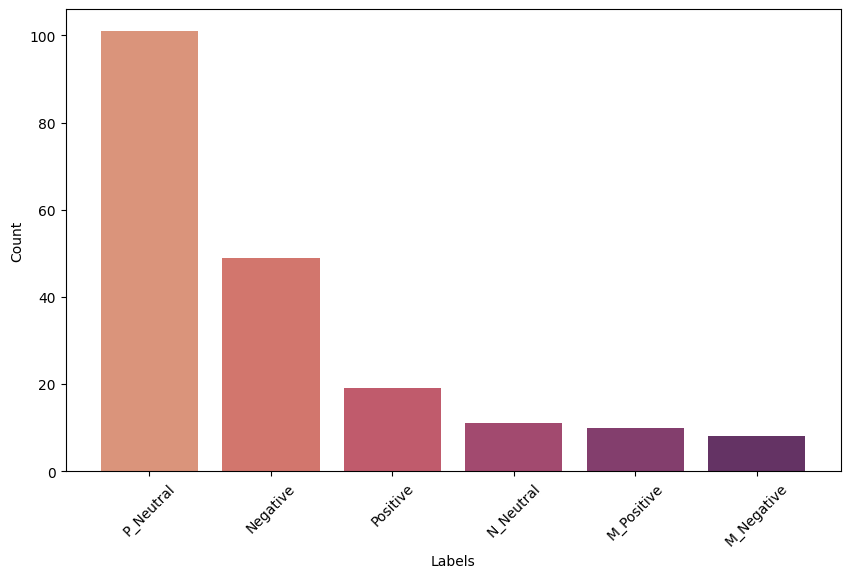

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.barplot(x=df1_labels.index, y=df1_labels.values, hue=df1_labels.index, palette='flare', legend=False)
plt.xlabel('Labels')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.plot()

## Label distribution, non-procedural speeches only

In [8]:
df2 = df1[df1['chair'] != True]
df2_labels = df2['final_tag'].value_counts()
df2_labels

final_tag
Negative      45
Positive      19
P_Neutral     10
M_Positive    10
M_Negative     8
N_Neutral      5
Name: count, dtype: int64

[]

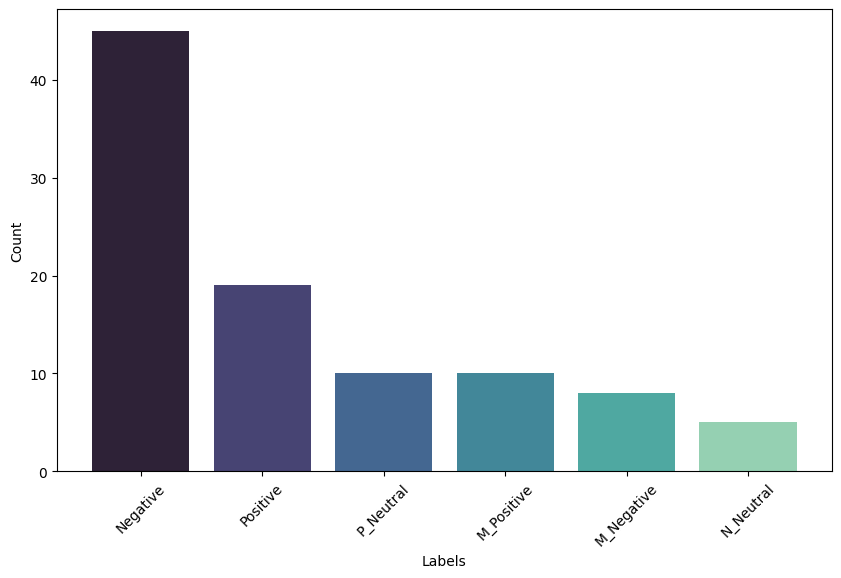

In [9]:
plt.figure(figsize=(10,6))
sns.barplot(x=df2_labels.index, y=df2_labels.values, hue=df2_labels.index, palette='mako', legend=False)
plt.xlabel('Labels')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.plot()

Label distribution for procedural speech

In [11]:
df3 = df1[df1['chair'] == True]
df3_labels = df3['final_tag'].value_counts()
df3_labels

final_tag
P_Neutral    91
N_Neutral     6
Negative      4
Name: count, dtype: int64

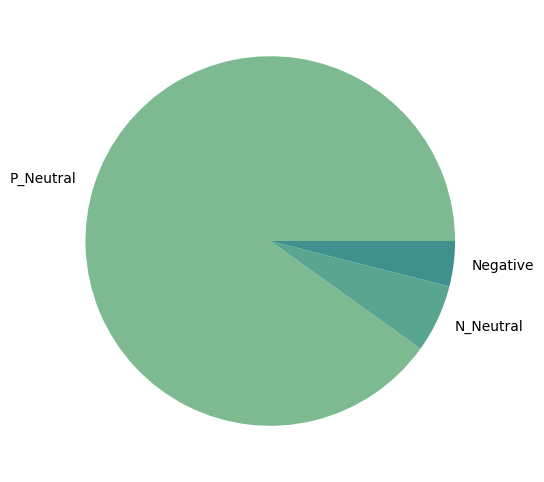

In [18]:
palette = sns.color_palette('crest')
plt.figure(figsize=(10,6))
plt.pie(df3_labels, labels=df3_labels.index, colors=palette)
plt.show()


# Label distribution per annotators

In [19]:
annotator1_labels = df['tag_tamara'].value_counts()
annotator2_labels = df1['tag_katja'].value_counts()
annotators = pd.DataFrame({
    'annotator1': annotator1_labels,
    'annotator2': annotator2_labels
})
#annotators.head()

In [20]:
annotators = annotators.reset_index().rename(columns={'index':'label'})

In [21]:
annotators = annotators.melt(id_vars='label', var_name='annotator', value_name='count')
annotators

,label,annotator,count
0,M_Negative,annotator1,13
1,M_Positive,annotator1,7
2,N_Neutral,annotator1,10
3,Negative,annotator1,39
4,P_Neutral,annotator1,112
5,Positive,annotator1,17
6,M_Negative,annotator2,9
7,M_Positive,annotator2,10
8,N_Neutral,annotator2,10
9,Negative,annotator2,53


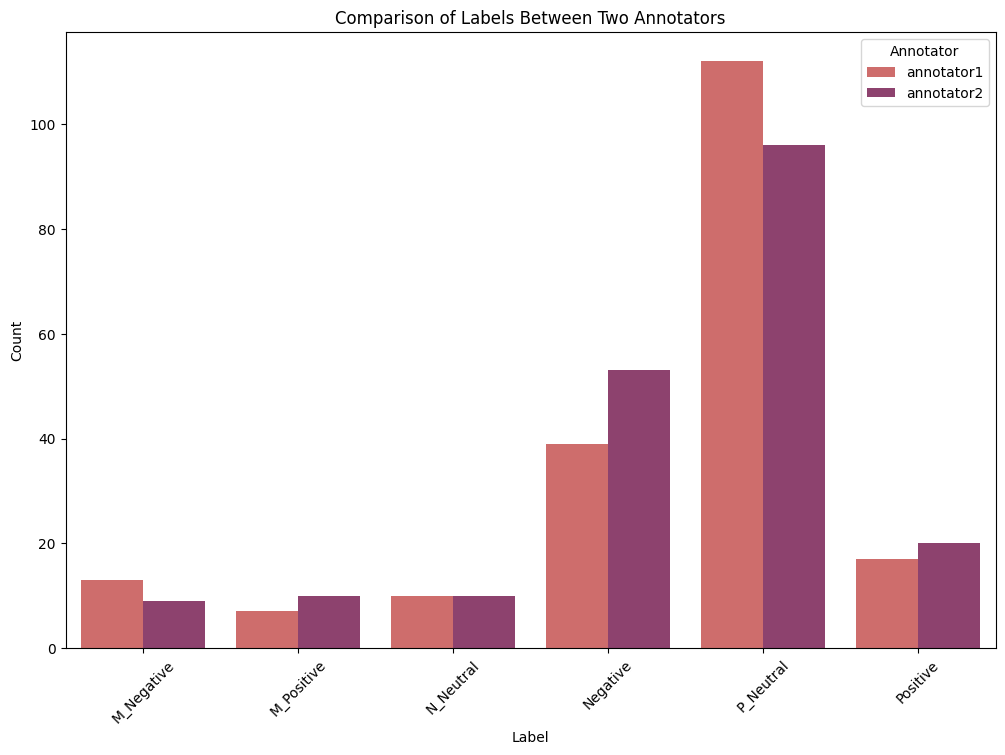

In [22]:
plt.figure(figsize=(12, 8))
sns.barplot(x='label', y='count', hue='annotator', data=annotators, palette='flare')
plt.xlabel('Label')
plt.ylabel('Count')
plt.title('Comparison of Labels Between Two Annotators')
plt.xticks(rotation=45)  
plt.legend(title='Annotator')
plt.show()

## Label distribution per annotator - non-procedural only

In [23]:
annotator1_labels = df2['tag_tamara'].value_counts()
annotator2_labels = df2['tag_katja'].value_counts()
annotators_non = pd.DataFrame({
    'annotator1': annotator1_labels,
    'annotator2': annotator2_labels
})
#annotators.head()

In [24]:
annotators_non = annotators_non.reset_index().rename(columns={'index':'label'})
annotators_non = annotators_non.melt(id_vars='label', var_name='annotator', value_name='count')
annotators_non

,label,annotator,count
0,M_Negative,annotator1,13
1,M_Positive,annotator1,7
2,N_Neutral,annotator1,3
3,Negative,annotator1,39
4,P_Neutral,annotator1,18
5,Positive,annotator1,17
6,M_Negative,annotator2,8
7,M_Positive,annotator2,10
8,N_Neutral,annotator2,4
9,Negative,annotator2,47


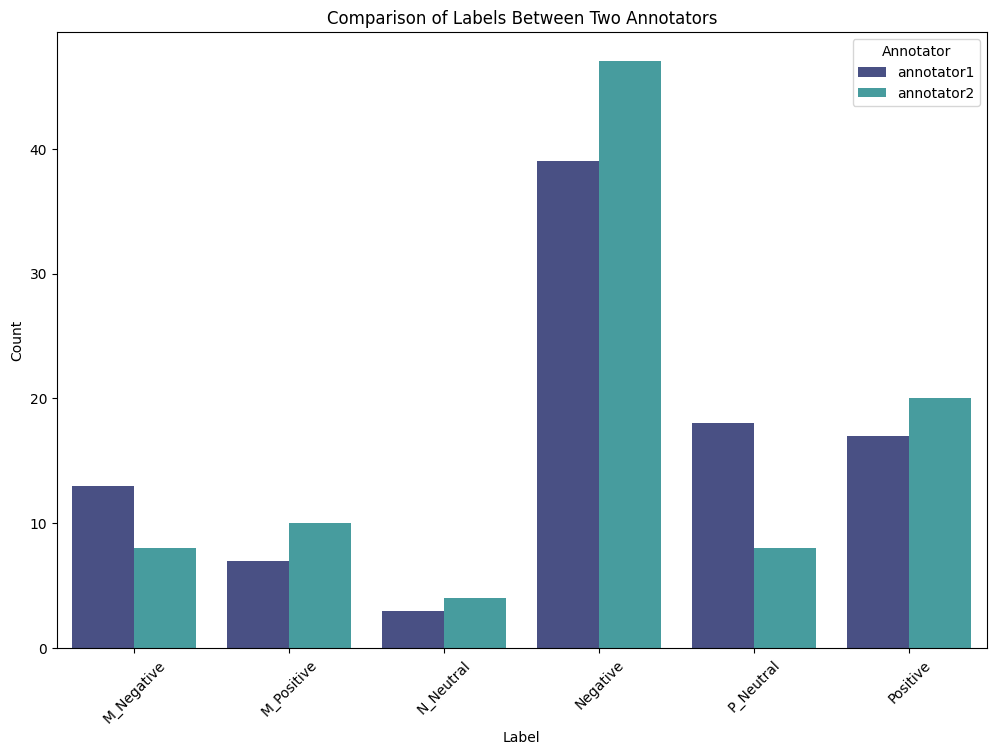

In [25]:
plt.figure(figsize=(12, 8))
sns.barplot(x='label', y='count', hue='annotator', data=annotators_non, palette='mako')
plt.xlabel('Label')
plt.ylabel('Count')
plt.title('Comparison of Labels Between Two Annotators')
plt.xticks(rotation=45)  
plt.legend(title='Annotator')
plt.show()

# Label distribution - procedural-only

In [26]:
annotator1_procedural = df3['tag_tamara'].value_counts()
annotator2_procedural = df3['tag_katja'].value_counts()
annotators_procedural = pd.DataFrame({
    'annotator1': annotator1_procedural,
    'annotator2': annotator2_procedural 
})
annotators_procedural.head()

,annotator1,annotator2
M_Negative,NaN,1
N_Neutral,7.0,6
Negative,NaN,6
P_Neutral,94.0,88


In [29]:
procedural = annotators_procedural.reset_index().rename(columns={'index':'label'})
procedural = procedural.melt(id_vars='label', var_name='annotator', value_name='count')
procedural

,label,annotator,count
0,M_Negative,annotator1,NaN
1,N_Neutral,annotator1,7.0
2,Negative,annotator1,NaN
3,P_Neutral,annotator1,94.0
4,M_Negative,annotator2,1.0
5,N_Neutral,annotator2,6.0
6,Negative,annotator2,6.0
7,P_Neutral,annotator2,88.0


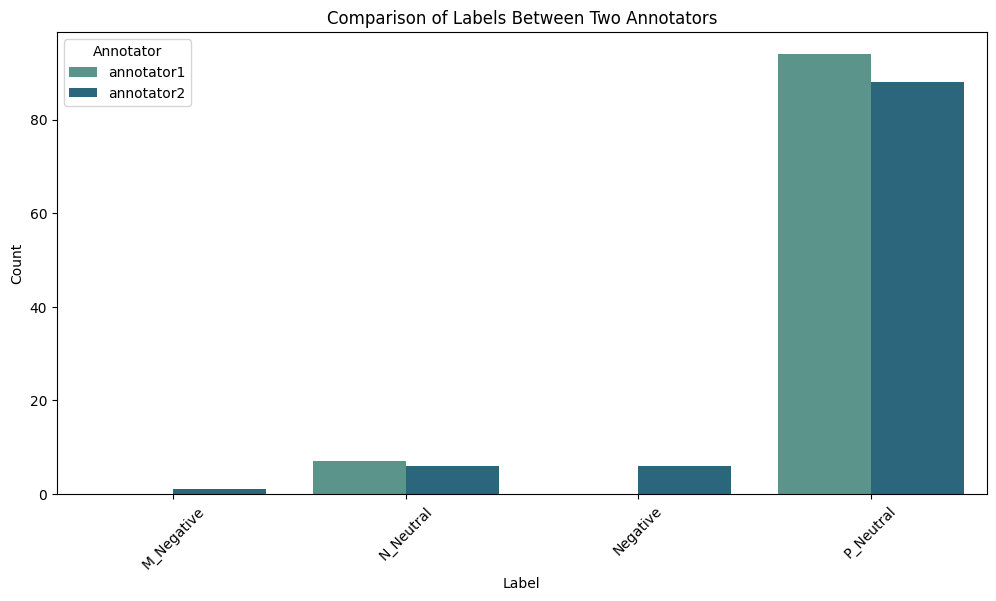

In [31]:
plt.figure(figsize=(12, 6))
sns.barplot(x='label', y='count', hue='annotator', data=procedural, palette='crest')
plt.xlabel('Label')
plt.ylabel('Count')
plt.title('Comparison of Labels Between Two Annotators')
plt.xticks(rotation=45)  
plt.legend(title='Annotator')
plt.show()